In [4]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

In [5]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [6]:
image_cut = image[55:155, 0:1800]

Text(0, 0.5, 'Flux')

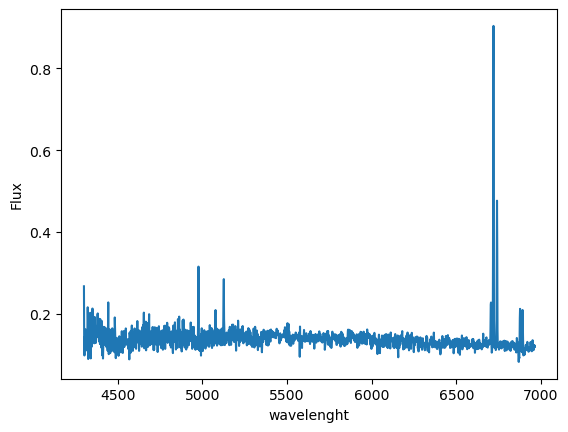

In [13]:
flux = image_cut[58, 0:]
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
plt.plot(wavelenghts, flux)
plt.xlabel('wavelenght')
plt.ylabel('Flux')

In [8]:
image_error = hdul[1].data
image_error_cut = image_error[55:155, 0:1800]

In [9]:
for i in range(100):
    flux = image_cut[i, 0:]
    flux_error = image_error_cut[i, 0:]
    SN = flux/flux_error
    f_wv = np.concatenate((wavelenghts.reshape(-1, 1), flux.reshape(-1, 1), flux_error.reshape(-1, 1), SN.reshape(-1, 1)), axis = 1)
    np.savetxt('55_155_0_1800_bin_1/spectrum_{}.txt'.format(i), f_wv)

Text(0, 0.5, 'S/N')

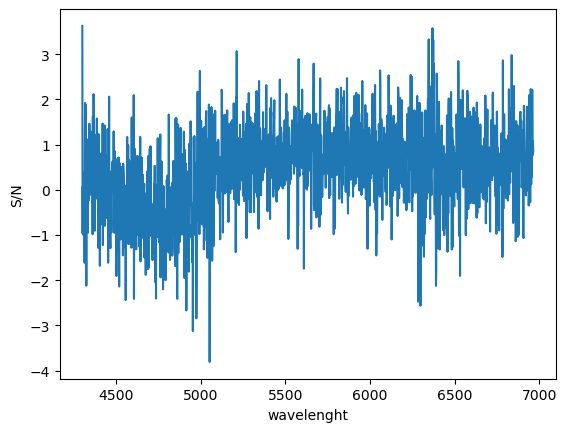

In [12]:
plt.plot(wavelenghts, SN)
plt.xlabel('wavelenght')
plt.ylabel('S/N')